## 1. Setup

In [55]:
import sys
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sparse
import torch
import gseapy as gp
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'gseapy'

In [6]:
REPO_ROOT = Path("/home/ec2-user/SageMaker/scldm_cd4/")

sys.path.insert(0, str(REPO_ROOT / "src"))  # for notebook_inference.py (not part of the scg_vae package)

from notebook_inference import inference  # noqa: E402
from scg_vae.evaluations import MMDLoss, RBFKernel, wasserstein

## 2. Paths (mirrors `notebooks/quickstart_tutorial.ipynb`)

In [12]:
INFERENCE_CONFIG_PATH = str(REPO_ROOT / "experiments" / "config")
INFERENCE_CONFIG_NAME = "inference_fm"
CHECKPOINT_PATH = "/home/ec2-user/.cache/huggingface/hub/models--biohub--scldm_cd4/snapshots/39552083e747f2846dfb16ee854197beb90a3061/model.safetensors"         # modify as necessary
OUTPUT_DIR = REPO_ROOT / "inference_outputs" / "knockout_eval"     # modify as necessary
TRAIN_ADATA_PATH = REPO_ROOT / "quickstart_data" / "train_hvg" / "adata_1.h5ad"
QUERY_DIR = OUTPUT_DIR / "queries"
QUERY_DIR.mkdir(parents=True, exist_ok=True)

## 3. Discover the model's known vocabulary

In [13]:
train_adata = ad.read_h5ad(TRAIN_ADATA_PATH)

donor_categories = sorted(train_adata.obs["donor_id"].astype(str).unique())
timepoint_categories = sorted(train_adata.obs["experimental_perturbation_time_point"].astype(str).unique())
guide_categories = sorted(train_adata.obs["guide_target_ensembl"].astype(str).unique())

print(f"Donors ({len(donor_categories)}): {donor_categories}")
print(f"Timepoints ({len(timepoint_categories)}): {timepoint_categories}")
print(f"Known perturbations: {len(guide_categories)} total, e.g. {guide_categories[:10]}")

# Try to auto-detect the non-targeting-control label (dataset-dependent naming).
control_candidates = [
    g for g in guide_categories
    if any(kw in g.lower() for kw in ("non-target", "non_target", "ntc", "control", "safe", "scramble"))
]
print(f"Likely control label candidate(s): {control_candidates}")

Donors (4): ['CE0006864', 'CE0008162', 'CE0008678', 'CE0010866']
Timepoints (3): ['Rest', 'Stim48hr', 'Stim8hr']
Known perturbations: 6866 total, e.g. ['ENSG00000000003', 'ENSG00000000457', 'ENSG00000000938', 'ENSG00000001036', 'ENSG00000001084', 'ENSG00000001460', 'ENSG00000001461', 'ENSG00000001630', 'ENSG00000002016', 'ENSG00000002330']
Likely control label candidate(s): ['NTC']


In [25]:
HGNC_PATH = REPO_ROOT / "hgnc_genes.txt"  # adjust if it lives elsewhere

hgnc = pd.read_csv(HGNC_PATH, sep="\t")
hgnc = hgnc.rename(columns={
    "Approved symbol": "hgnc_symbol",
    "Ensembl ID(supplied by Ensembl)": "ensembl_id",
})[["hgnc_symbol", "ensembl_id"]]
hgnc = hgnc.dropna(subset=["ensembl_id"]).drop_duplicates(subset=["ensembl_id"])

symbol_to_ensembl = dict(zip(hgnc["hgnc_symbol"], hgnc["ensembl_id"]))
ensembl_to_symbol = dict(zip(hgnc["ensembl_id"], hgnc["hgnc_symbol"]))

print(f"Loaded {len(hgnc)} HGNC symbol <-> Ensembl ID pairs (rows with no Ensembl ID were dropped)")

Loaded 40566 HGNC symbol <-> Ensembl ID pairs (rows with no Ensembl ID were dropped)


## 4. Set the experiment parameters

In [31]:
DONOR_ID = donor_categories[0]
TIMEPOINT = 'Stim48hr'
CONTROL_LABEL = control_candidates[0] if len(control_candidates) == 1 else "<fill in from guide_categories above>"
TARGET_GENE_SYMBOL = "LCP2"  # <- set this to the HGNC symbol you want to knock out

if TARGET_GENE_SYMBOL not in symbol_to_ensembl:
    raise KeyError(f"{TARGET_GENE_SYMBOL} has no Ensembl ID on record in {HGNC_PATH.name}")

TARGET_GENE = symbol_to_ensembl[TARGET_GENE_SYMBOL]
print(f"{TARGET_GENE_SYMBOL} -> {TARGET_GENE}")

assert TARGET_GENE in guide_categories, (
    f"{TARGET_GENE} ({TARGET_GENE_SYMBOL}) is not one of the checkpoint's known perturbations"
)

N_CELLS = 500
SEED = 42

assert CONTROL_LABEL in guide_categories, "CONTROL_LABEL must be one of the checkpoint's known perturbations"

LCP2 -> ENSG00000043462


## 5. Build counterfactual query datasets

In [32]:
def sample_base_cells(adata: ad.AnnData, donor_id: str, timepoint: str, n_cells: int, seed: int) -> ad.AnnData:
    mask = (adata.obs["donor_id"].astype(str) == donor_id) & (
        adata.obs["experimental_perturbation_time_point"].astype(str) == timepoint
    )
    subset = adata[mask]
    if subset.n_obs == 0:
        raise ValueError(f"No cells found for donor={donor_id}, timepoint={timepoint}")
    rng = np.random.default_rng(seed)
    idx = rng.choice(subset.n_obs, size=n_cells, replace=subset.n_obs < n_cells)
    return subset[idx].copy()


def build_query(base_cells: ad.AnnData, guide_label: str) -> ad.AnnData:
    query = base_cells.copy()
    query.obs["guide_target_ensembl"] = pd.Categorical([guide_label] * query.n_obs)
    return query


base_cells = sample_base_cells(train_adata, DONOR_ID, TIMEPOINT, N_CELLS, SEED)
query_conditional = build_query(base_cells, TARGET_GENE)
query_control = build_query(base_cells, CONTROL_LABEL)

conditional_path = QUERY_DIR / "query_conditional.h5ad"
control_path = QUERY_DIR / "query_control.h5ad"
query_conditional.write_h5ad(conditional_path)
query_control.write_h5ad(control_path)

print(f"Wrote {query_conditional.n_obs} cells to {conditional_path}")
print(f"Wrote {query_control.n_obs} cells to {control_path}")

Wrote 500 cells to /home/ec2-user/SageMaker/scldm_cd4/inference_outputs/knockout_eval/queries/query_conditional.h5ad
Wrote 500 cells to /home/ec2-user/SageMaker/scldm_cd4/inference_outputs/knockout_eval/queries/query_control.h5ad


In [33]:
for adata_obj in (knockout_cells, control_cells):
    adata_obj.var["hgnc_symbol"] = adata_obj.var_names.map(ensembl_to_symbol)

## 6. Run generation for each condition

In [34]:
def run_generation(query_path: Path, run_name: str) -> ad.AnnData:
    out = inference(
        config_path=INFERENCE_CONFIG_PATH,
        config_name=INFERENCE_CONFIG_NAME,
        checkpoint_path=CHECKPOINT_PATH,
        output_dir=str(OUTPUT_DIR / run_name),
        dataset_generation_idx=0,
        seed=SEED,
        batch_size=32,
        device="cuda",
        overrides=[
            "model.batch_size=32",
            f"datamodule.dataset_params.marson_hvg.adata_test={query_path.resolve()}",
        ],
    )
    return out

gen_knockout_raw = run_generation(conditional_path, "knockout")
gen_control_raw = run_generation(control_path, "control")

knockout_cells = gen_knockout_raw[gen_knockout_raw.obs["dataset"] == "generated_conditional"].copy()
control_cells = gen_control_raw[gen_control_raw.obs["dataset"] == "generated_conditional"].copy()

print(f"Generated {knockout_cells.n_obs} knockout cells, {control_cells.n_obs} control cells")
print(knockout_cells.obs["guide_target_ensembl"].value_counts())
print(control_cells.obs["guide_target_ensembl"].value_counts())


Seed set to 42


✓ Configuration loaded: inference_fm
Loading original config from /home/ec2-user/.cache/huggingface/hub/models--biohub--scldm_cd4/snapshots/39552083e747f2846dfb16ee854197beb90a3061/config.yaml
Setting up datamodule...
INFO     Effective steps: 468, Num epochs: 1, World size: 1, Batch size: 32, N cells: 15000                        
INFO     Using IterableDistributedAnnDataCollectionDataset                                                         
✓ Datamodule ready
Instantiating model...
INFO     Compiling model with default mode.                                                                        
✓ Model ready
Loading SafeTensors checkpoint: /home/ec2-user/.cache/huggingface/hub/models--biohub--scldm_cd4/snapshots/39552083e747f2846dfb16ee854197beb90a3061/model.safetensors


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Setting up trainer (mode: predict)...
INFO     Using IterableDistributedAnnDataCollectionDataset                                                         
Running generation...
INFO     Using IterableDistributedAnnDataCollectionDataset                                                         


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/ec2-user/SageMaker/scldm_cd4/venv/scldm_cd4/lib/python3.11/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/home/ec2-user/SageMaker/scldm_cd4/venv/scldm_cd4/lib/python3.11/site-packages/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(
/home/ec2-user/SageMaker/scldm_cd4/venv/scldm_cd4/lib/python3.11/site-packages/pytorch_lightning/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In com

...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/ec2-user/SageMaker/scldm_cd4/venv/scldm_cd4/lib/python3.11/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/home/ec2-user/SageMaker/scldm_cd4/venv/scldm_cd4/lib/python3.11/site-packages/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(
/home/ec2-user/SageMaker/scldm_cd4/venv/scldm_cd4/lib/python3.11/site-packages/pytorch_lightning/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In com

Output()

INFO     Processing batch 1/8 (12.5%)                                                                              


/home/ec2-user/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


INFO     Processing generation output                                                                              
✓ Saved 1000 cells to /home/ec2-user/SageMaker/scldm_cd4/inference_outputs/knockout_eval/control/marson_hvg_generated_0.h5ad
Generated 500 knockout cells, 500 control cells
guide_target_ensembl
ENSG00000043462    500
Name: count, dtype: int64
guide_target_ensembl
NTC    500
Name: count, dtype: int64


In [40]:
for adata_obj in (knockout_cells, control_cells):
    adata_obj.var["hgnc_symbol"] = adata_obj.var_names.map(ensembl_to_symbol)

## 7. Quantify the effect

### 7a. Pseudobulk shift (matches the Δ-based metrics used to benchmark scLDM)

In [41]:
def to_dense(x):
    return x.toarray() if sparse.issparse(x) else np.asarray(x)

mean_knockout = to_dense(knockout_cells.X).mean(axis=0)
mean_control = to_dense(control_cells.X).mean(axis=0)
delta = np.asarray(mean_knockout - mean_control).ravel()

delta_series = pd.Series(delta, index=knockout_cells.var["hgnc_symbol"]).sort_values(key=np.abs, ascending=False)
print("Top 20 genes by |predicted pseudobulk effect|:")
print(delta_series.head(20))

Top 20 genes by |predicted pseudobulk effect|:
hgnc_symbol
GZMA      39.214001
LTB       38.612000
IL2RA    -32.029999
MAL       31.153999
TXNIP     19.818001
H1-5     -18.605999
GBP5      18.510000
VIM       16.836000
GZMB     -13.863999
CXCL8    -13.622000
CXCR4     12.976000
TUBA1B   -12.641999
CCL4     -11.340000
MT-ND4   -11.310000
IFI44L    10.736000
CCL3     -10.518000
SYNE2     10.434000
DDIT4    -10.230000
MT-CO1   -10.078001
TRIM22     9.822000
dtype: float32


### 7b. Differential expression (gene-level, more biologically actionable)

In [48]:
combined = ad.concat(
    {"knockout": knockout_cells, "control": control_cells},
    label="group",
    index_unique="-",
)
sc.pp.normalize_total(combined, target_sum=10_000)
sc.pp.log1p(combined)

sc.tl.rank_genes_groups(combined, groupby="group", groups=["knockout"], reference="control", method="wilcoxon")
deg_df = sc.get.rank_genes_groups_df(combined, group="knockout")
deg_df["hgnc_symbol"] = deg_df["names"].map(ensembl_to_symbol)
deg_df = deg_df[["hgnc_symbol", "logfoldchanges", "pvals"]].copy()
significant_degs = deg_df[(deg_df["pvals"] < 0.05) & (deg_df["logfoldchanges"].abs() > 0.25)]

print(f"{len(significant_degs)} significant DEGs out of {combined.n_vars} genes tested")
print(significant_degs.sort_values("pvals").head(20))

871 significant DEGs out of 3699 genes tested
     hgnc_symbol  logfoldchanges          pvals
3698       IL2RA       -4.203723  2.304825e-121
0            MAL        2.833800  2.340780e-109
3697       ZBED2       -4.134599   3.972631e-84
3696      ZBTB32       -4.575952   1.160044e-81
1         IFI44L        4.742366   6.048690e-79
2           GBP5        2.299076   9.055363e-73
3          SYNE2        3.762097   1.290806e-72
4            LTB        2.582821   9.062612e-70
5          TXNIP        2.926593   5.566412e-67
3695    C12orf75       -2.510444   2.720466e-64
6         TRIM22        3.636243   1.449356e-63
3694        ELL2       -3.165387   1.595624e-63
3693       PSAT1       -3.612059   4.106583e-62
3692       DUSP4       -3.821678   5.535456e-61
3691        LAG3       -3.365086   1.059475e-60
3690       HSPE1       -3.353323   3.588783e-60
3689       WARS1       -2.999692   2.208568e-59
3688      MAD2L1       -3.066082   3.911139e-58
3687        TYMS       -3.145084   3.73603

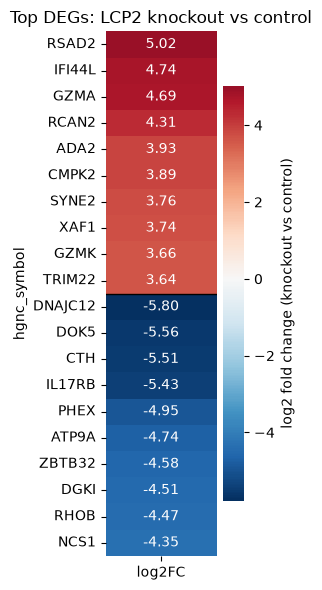

In [52]:
# --- top 10 up- and top 10 down-regulated significant DEGs, by log2FC ---
top_up = significant_degs.sort_values("logfoldchanges", ascending=False).head(10)
top_down = significant_degs.sort_values("logfoldchanges", ascending=True).head(10)
top_genes = pd.concat([top_up, top_down])

logfc_matrix = top_genes.set_index("hgnc_symbol")[["logfoldchanges"]].rename(
    columns={"logfoldchanges": "log2FC"}
)

fig, ax = plt.subplots(figsize=(3, 6))
sns.heatmap(
    logfc_matrix,
    cmap="RdBu_r",
    center=0,                     # 0 = no change, so red/blue = up/down directly
    annot=True, fmt=".2f",
    cbar_kws={"label": "log2 fold change (knockout vs control)"},
    ax=ax,
)
ax.axhline(len(top_up), color="black", linewidth=1)  # separates "up" block from "down" block
ax.set_title(f"Top DEGs: {TARGET_GENE_SYMBOL} knockout vs control")
plt.tight_layout()
plt.show()

In [ ]:
GO_BP_LIBRARY = "GO_Biological_Process_2023"

# --- build the full ranked list: HGNC symbol -> signed test statistic ---
# `scores` is the signed Wilcoxon z-score from rank_genes_groups (positive = up in knockout)
ranked = deg_df[["names", "scores"]].copy()
ranked["hgnc_symbol"] = ranked["names"].map(ensembl_to_symbol)
ranked = ranked.dropna(subset=["hgnc_symbol"])

# if multiple Ensembl IDs map to the same symbol, keep the most extreme score
ranked = ranked.reindex(ranked["scores"].abs().sort_values(ascending=False).index)
ranked = ranked.drop_duplicates(subset="hgnc_symbol", keep="first")

rnk = ranked[["hgnc_symbol", "scores"]].sort_values("scores", ascending=False)

print(f"Ranked list: {len(rnk)} genes (from {len(deg_df)} tested)")

# --- run preranked GSEA ---
pre_res = gp.prerank(
    rnk=rnk,
    gene_sets=GO_BP_LIBRARY,
    threads=4,
    min_size=5,
    max_size=1000,
    permutation_num=1000,   # lower (e.g. 100) for a quick pass, raise for stable FDR
    outdir=None,
    seed=42,
)

res2d = pre_res.res2d.astype({"NES": float, "FDR q-val": float})

# --- top 10 up (positive NES) and top 10 down (negative NES) pathways ---
top_up_terms = res2d.sort_values("NES", ascending=False).head(10)
top_down_terms = res2d.sort_values("NES", ascending=True).head(10)
plot_df = pd.concat([top_up_terms, top_down_terms]).sort_values("NES")

# --- diverging horizontal bar plot ---
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#d73027" if nes > 0 else "#4575b4" for nes in plot_df["NES"]]
ax.barh(plot_df["Term"], plot_df["NES"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Normalized Enrichment Score (NES)\n(positive = enriched toward up-regulated end, negative = down-regulated end)")
ax.set_title(f"Top GO:BP pathways (GSEA): {TARGET_GENE_SYMBOL} knockout vs control")
plt.tight_layout()
plt.show()

In [61]:
significant_degs.to_csv(OUTPUT_DIR / f"{TARGET_GENE_SYMBOL}_diffexp.csv", index=False)

### 7c. Distributional distance in latent space

In [38]:
z_knockout = torch.tensor(knockout_cells.obsm["z"], dtype=torch.float32)
z_control = torch.tensor(control_cells.obsm["z"], dtype=torch.float32)

mmd = MMDLoss(RBFKernel(scale=1.0))(z_knockout, z_control).item()
w_dist = wasserstein(z_knockout, z_control)

print(f"MMD(knockout, control)         = {mmd:.4f}")
print(f"Wasserstein(knockout, control) = {w_dist:.4f}")
print("Larger values => the model predicts a stronger shift away from control under this knockout.")

MMD(knockout, control)         = 0.0040
Wasserstein(knockout, control) = 29.9173
Larger values => the model predicts a stronger shift away from control under this knockout.


In [60]:
pd.DataFrame({"Wasserstein_dist": [w_dist]}).to_csv(OUTPUT_DIR / f"{TARGET_GENE_SYMBOL}_diffexp.csv", index=False)

,Wasserstein_dist
0,29.917293


## 8. Visualize

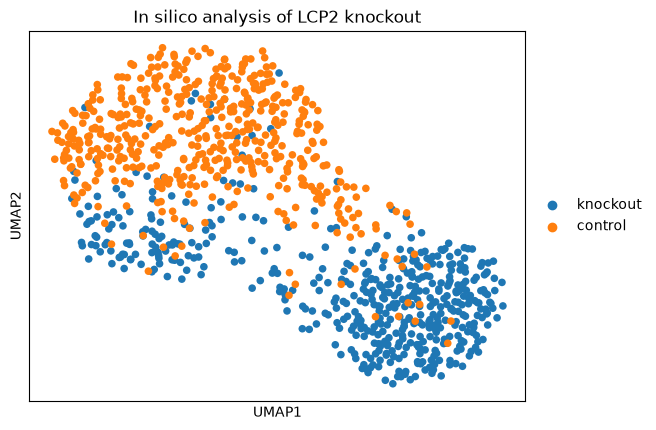

In [47]:
sc.pp.pca(combined)
sc.pp.neighbors(combined)
sc.tl.umap(combined)

sc.pl.umap(combined, color="group", title=f"In silico analysis of {TARGET_GENE_SYMBOL} knockout")